<a href="https://colab.research.google.com/github/LourdesBranchi/camus-lv-segmentation/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Dataset CAMUS
**Cardiac Acquisitions for Multi-structure Ultrasound Segmentation**

Este notebook analiza el dataset para justificar las decisiones de diseño del proyecto:
- Distribución de clases (justifica el uso de Dice Loss)
- Variabilidad de tamaños (justifica el resize a 256×256)
- Calidad de imagen (justifica el data augmentation conservador)
- Ejemplos visuales (para el paper IEEE)

In [4]:
import os, glob, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import SimpleITK as sitk
from collections import Counter

## Montar Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Clonar repositorio

In [2]:
import os, sys

%cd /content
!rm -rf /content/camus-lv-segmentation
!git clone https://github.com/LourdesBranchi/camus-lv-segmentation.git
%cd /content/camus-lv-segmentation
!pip install -r requirements.txt -q

sys.path.insert(0, '/content/camus-lv-segmentation/src')
print('Setup completo.')

/content
Cloning into 'camus-lv-segmentation'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 65 (delta 27), reused 42 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 291.93 KiB | 10.07 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/camus-lv-segmentation
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.0 MB/s eta 0:00:00
Setup completo.


## Descargar dataset de Kaggle

In [3]:
from google.colab import userdata
import os

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(userdata.get('KAGGLE_API_TOKEN'))
os.chmod('/root/.kaggle/kaggle.json', 0o600)

%cd /content
!kaggle datasets download -d shoybhasan/camus-human-heart-data -q --force
!unzip -q camus-human-heart-data.zip -d dataset_raw
!rm camus-human-heart-data.zip
print('Dataset descargado.')

/content
Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
Dataset descargado.


In [5]:
# Descomprimir y definir DATA_ROOT
import zipfile

with zipfile.ZipFile('/content/dataset_raw/download', 'r') as z:
    z.extractall('/content/datos_corazon')

DATA_ROOT = '/content/datos_corazon/database_nifti'
print(f'Dataset listo en: {DATA_ROOT}')
!ls {DATA_ROOT} | head -5

Dataset listo en: /content/datos_corazon/database_nifti
patient0001
patient0002
patient0003
patient0004
patient0005


In [6]:
CLASS_NAMES  = {0: 'Fondo', 1: 'LV', 2: 'MYO', 3: 'LA'}
CLASS_COLORS = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255]], dtype=np.uint8)

VALID_SUFFIXES = ['_2CH_ED.nii.gz','_2CH_ES.nii.gz','_4CH_ED.nii.gz','_4CH_ES.nii.gz']

all_files   = glob.glob(os.path.join(DATA_ROOT,'**/*.nii.gz'), recursive=True)
image_files = [f for f in all_files
               if any(os.path.basename(f).endswith(s) for s in VALID_SUFFIXES)]
mask_files  = [f.replace('.nii.gz','_gt.nii.gz') for f in image_files
               if os.path.exists(f.replace('.nii.gz','_gt.nii.gz'))]

patient_ids = sorted(set(os.path.basename(f).split('_')[0] for f in image_files))
print(f'Pacientes: {len(patient_ids)}')
print(f'Imágenes:  {len(image_files)}')
print(f'Máscaras:  {len(mask_files)}')

Pacientes: 500
Imágenes:  2000
Máscaras:  2000


## 1. Distribución de clases

Justifica el uso de Dice Loss + CrossEntropy en lugar de CrossEntropy sola.

Calculando distribución de clases (puede tardar ~2 min)...

Distribución de clases:
  Clase 0 (Fondo): 77.07%
  Clase 1 (LV): 8.54%
  Clase 2 (MYO): 9.29%
  Clase 3 (LA): 5.10%


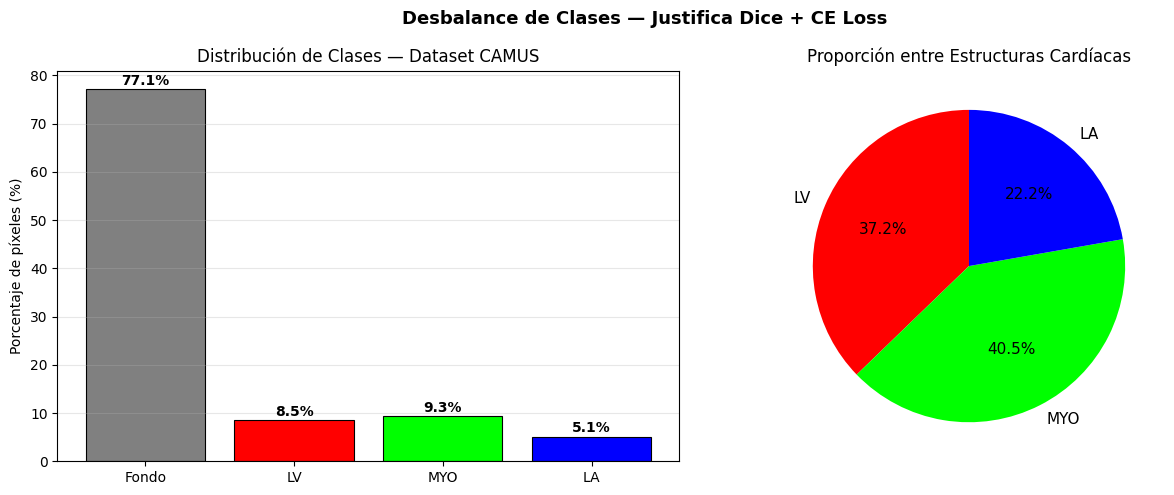

Figura guardada: eda_class_distribution.png


In [7]:
print('Calculando distribución de clases (puede tardar ~2 min)...')
pixel_counts = {0:0, 1:0, 2:0, 3:0}

for mask_path in mask_files:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(mask_path))
    if arr.ndim == 3: arr = arr[0]
    for c in range(4):
        pixel_counts[c] += (arr == c).sum()

total = sum(pixel_counts.values())
print('\nDistribución de clases:')
for c, name in CLASS_NAMES.items():
    pct = pixel_counts[c]/total*100
    print(f'  Clase {c} ({name}): {pct:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
names  = [CLASS_NAMES[c] for c in range(4)]
values = [pixel_counts[c]/total*100 for c in range(4)]
colors = [CLASS_COLORS[c]/255 for c in range(4)]
colors[0] = [0.5, 0.5, 0.5]  # gris para el fondo

ax1.bar(names, values, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Porcentaje de píxeles (%)')
ax1.set_title('Distribución de Clases — Dataset CAMUS')
for i, (name, val) in enumerate(zip(names, values)):
    ax1.text(i, val+0.3, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Solo clases cardíacas (sin fondo)
cardiac_names  = [CLASS_NAMES[c] for c in [1,2,3]]
cardiac_values = [pixel_counts[c]/total*100 for c in [1,2,3]]
cardiac_colors = [CLASS_COLORS[c]/255 for c in [1,2,3]]
ax2.pie(cardiac_values, labels=cardiac_names, colors=cardiac_colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize':11})
ax2.set_title('Proporción entre Estructuras Cardíacas')

plt.suptitle('Desbalance de Clases — Justifica Dice + CE Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_class_distribution.png')

## 2. Variabilidad de tamaños de imagen

Analizando tamaños de imagen (puede tardar ~1 min)...
Rango de alturas:  325 – 649 px
Rango de anchos:   382  – 787 px
Tamaños distintos: 24

Top 5 tamaños más frecuentes:
  (454, 551): 34 imágenes (17.0%)
  (519, 630): 26 imágenes (13.0%)
  (422, 512): 20 imágenes (10.0%)
  (584, 708): 18 imágenes (9.0%)
  (616, 748): 16 imágenes (8.0%)


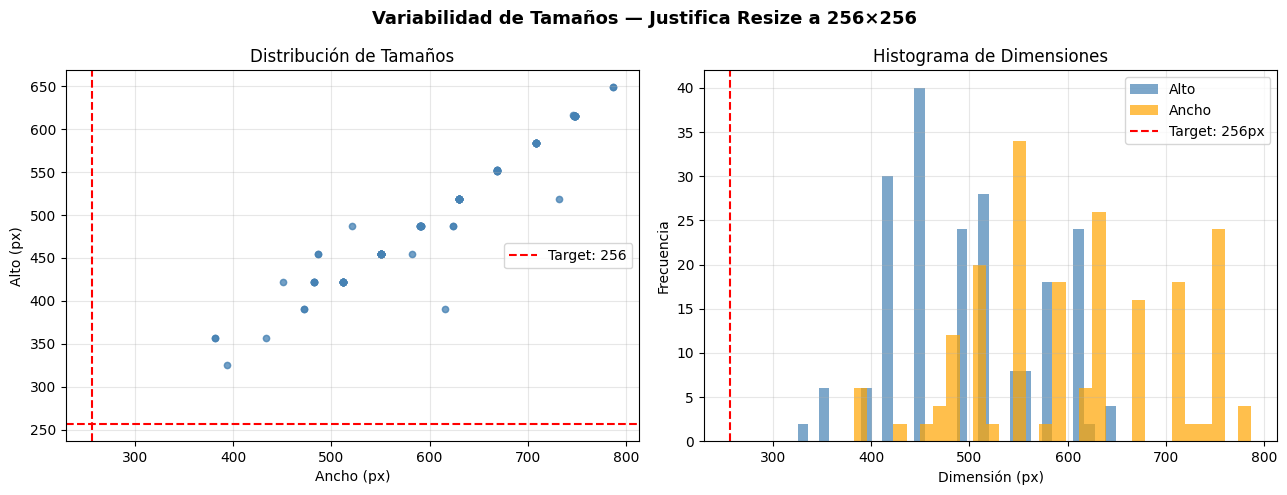

In [8]:
print('Analizando tamaños de imagen (puede tardar ~1 min)...')
sizes = []
for path in image_files[:200]:  # muestra de 200 para rapidez
    img  = sitk.ReadImage(path)
    size = img.GetSize()[::-1][-2:]
    sizes.append(size)

heights = [s[0] for s in sizes]
widths  = [s[1] for s in sizes]
size_counter = Counter(sizes)

print(f'Rango de alturas:  {min(heights)} – {max(heights)} px')
print(f'Rango de anchos:   {min(widths)}  – {max(widths)} px')
print(f'Tamaños distintos: {len(size_counter)}')
print('\nTop 5 tamaños más frecuentes:')
for size, count in size_counter.most_common(5):
    print(f'  {size}: {count} imágenes ({count/len(sizes)*100:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.scatter(widths, heights, alpha=0.5, s=20, color='steelblue')
ax1.axhline(256, color='red', linestyle='--', label='Target: 256')
ax1.axvline(256, color='red', linestyle='--')
ax1.set_xlabel('Ancho (px)'); ax1.set_ylabel('Alto (px)')
ax1.set_title('Distribución de Tamaños')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(heights, bins=30, alpha=0.7, label='Alto', color='steelblue')
ax2.hist(widths,  bins=30, alpha=0.7, label='Ancho', color='orange')
ax2.axvline(256, color='red', linestyle='--', label='Target: 256px')
ax2.set_xlabel('Dimensión (px)'); ax2.set_ylabel('Frecuencia')
ax2.set_title('Histograma de Dimensiones')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Variabilidad de Tamaños — Justifica Resize a 256×256', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ejemplos visuales del dataset

Figura central para el paper IEEE.

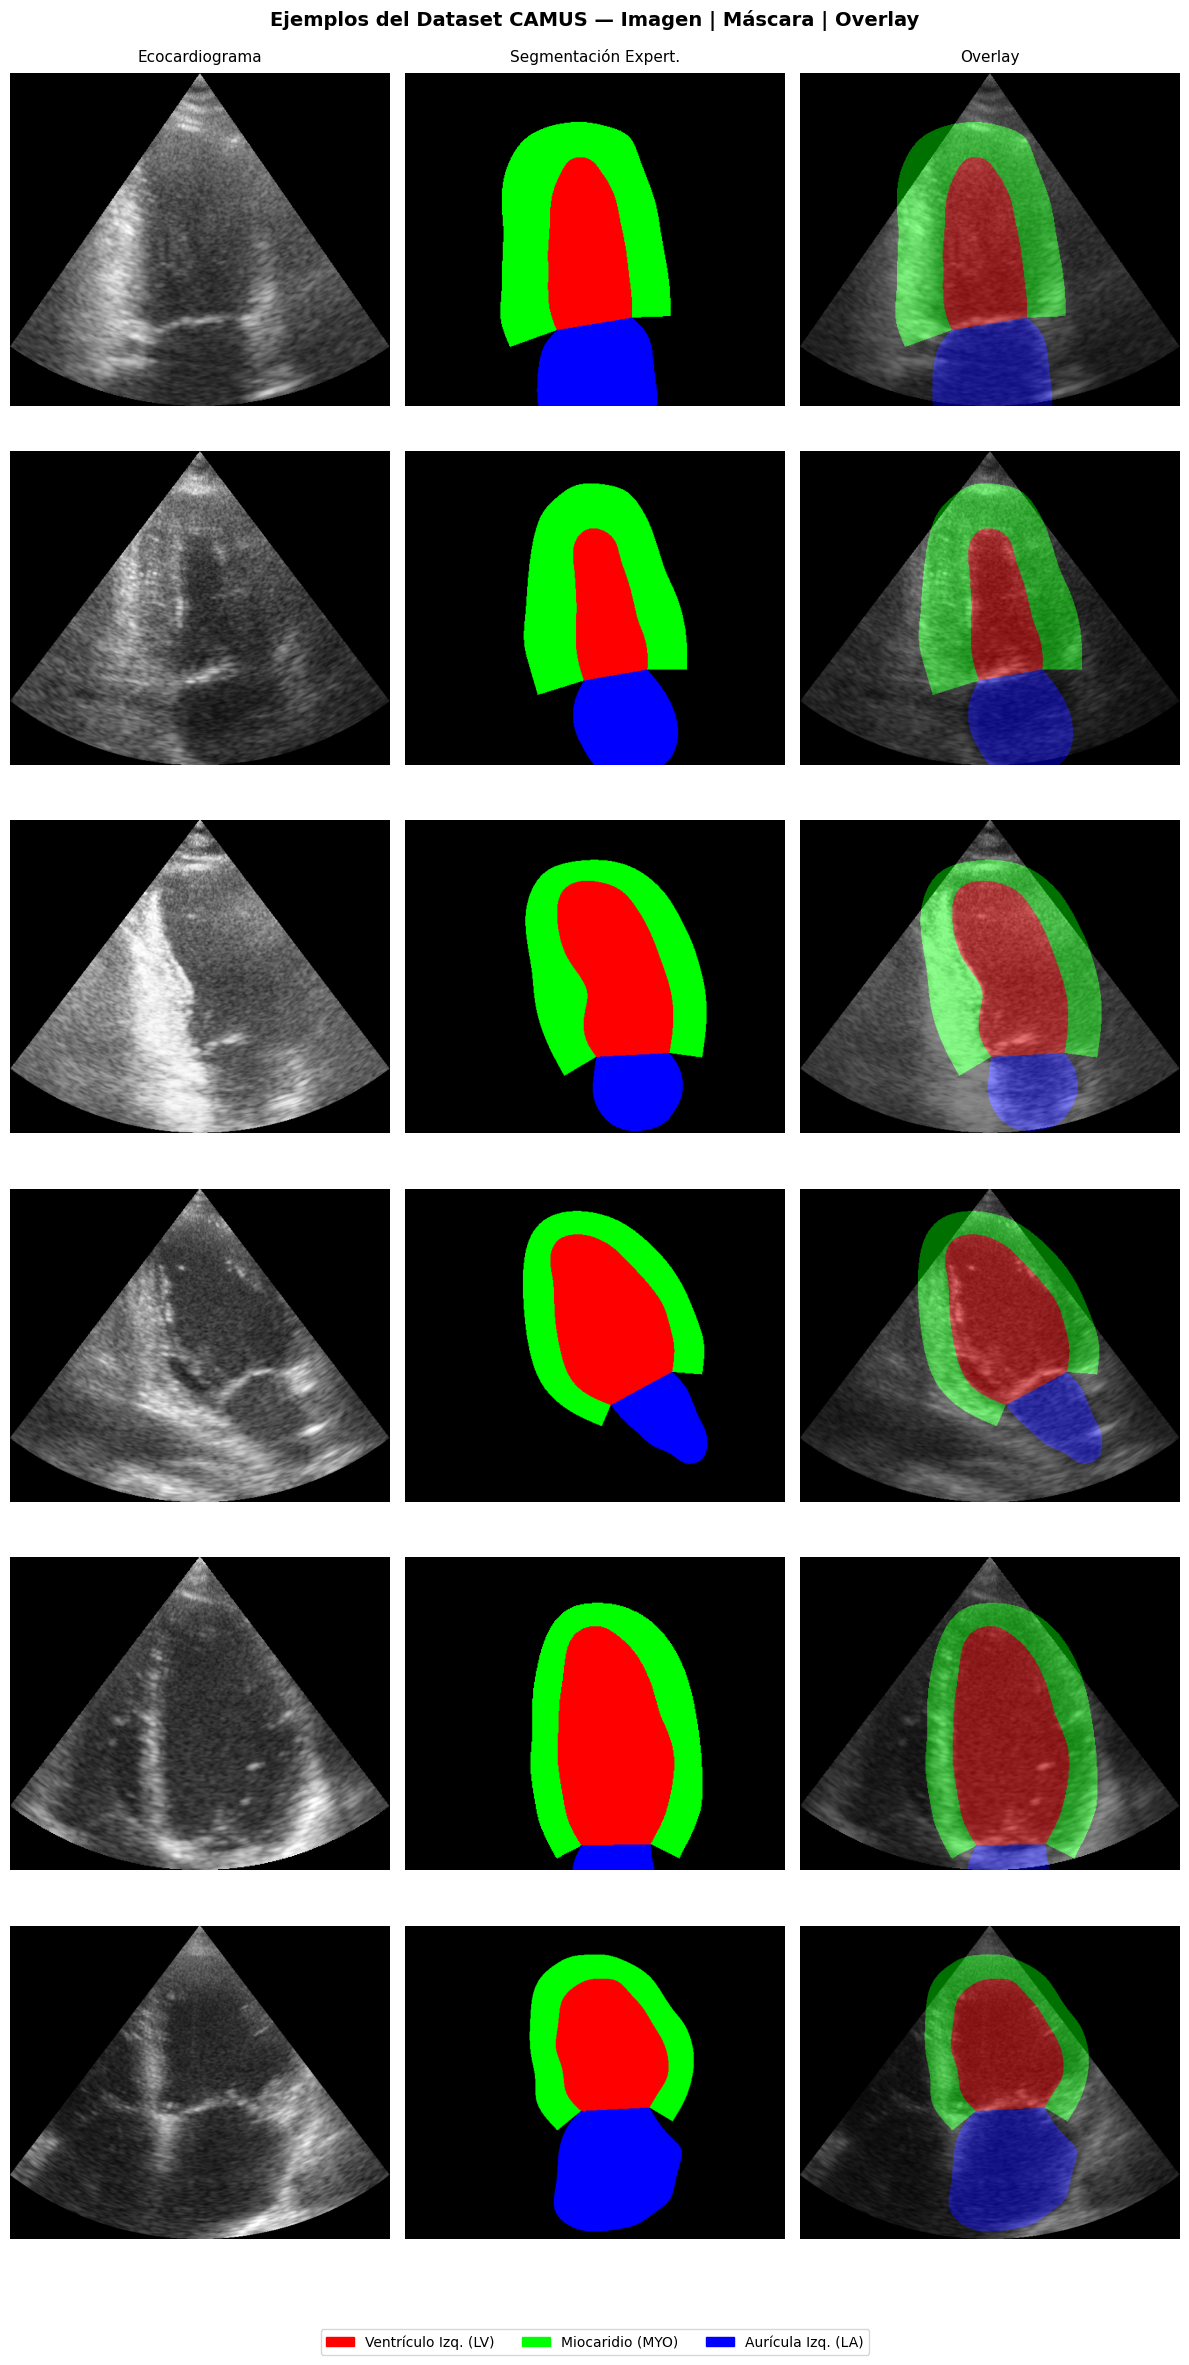

Figura guardada: eda_examples.png


In [13]:
def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c, color in enumerate(CLASS_COLORS):
        rgb[mask==c] = color
    return rgb

# Elegir 6 imágenes variadas
sample_indices = [0, 50, 100, 150, 200, 250]
sample_paths   = [image_files[i] for i in sample_indices if i < len(image_files)]
n_samples      = len(sample_paths)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples*4))
fig.suptitle('Ejemplos del Dataset CAMUS — Imagen | Máscara | Overlay\n', fontsize=14, fontweight='bold')

for col, title in enumerate(['Ecocardiograma', 'Segmentación Expert.', 'Overlay']):
    axes[0, col].set_title(title, fontsize=11, pad=8)

for i, img_path in enumerate(sample_paths):
    mask_path = img_path.replace('.nii.gz','_gt.nii.gz')
    img  = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).astype(np.float32)
    mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_path))
    if img.ndim  == 3: img  = img[0]
    if mask.ndim == 3: mask = mask[0]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    fname = os.path.basename(img_path)
    axes[i,0].imshow(img, cmap='gray'); axes[i,0].axis('off')
    axes[i,0].set_ylabel(fname, fontsize=7, rotation=0, labelpad=80)
    axes[i,1].imshow(mask_to_rgb(mask)); axes[i,1].axis('off')
    axes[i,2].imshow(img, cmap='gray'); axes[i,2].imshow(mask_to_rgb(mask), alpha=0.45); axes[i,2].axis('off')

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[1]/255, label='Ventrículo Izq. (LV)'),
    mpatches.Patch(color=CLASS_COLORS[2]/255, label='Miocaridio (MYO)'),
    mpatches.Patch(color=CLASS_COLORS[3]/255, label='Aurícula Izq. (LA)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('eda_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_examples.png')

## 4. Intensidad de píxeles

Justifica la normalización min-max elegida.

Analizando intensidades (muestra de 100 imágenes)...
Min global: 0.0
Max global: 255.0
Media:      44.4
Std:        53.6


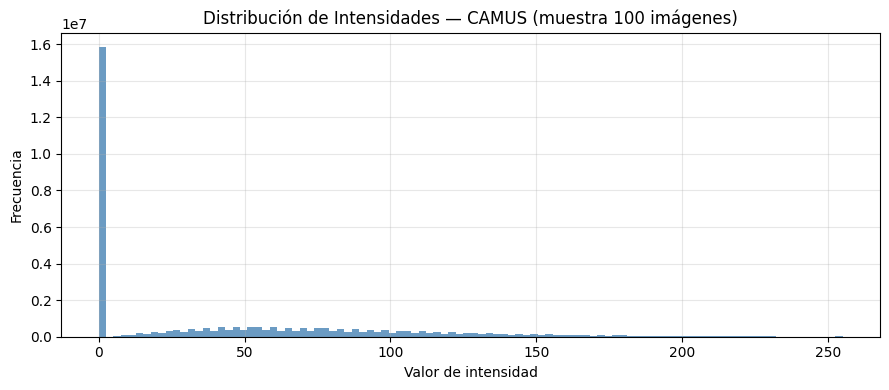

In [10]:
print('Analizando intensidades (muestra de 100 imágenes)...')
sample = image_files[:100]
all_pixels = []
for path in sample:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(path)).astype(np.float32)
    if arr.ndim == 3: arr = arr[0]
    all_pixels.extend(arr.flatten().tolist())

all_pixels = np.array(all_pixels)
print(f'Min global: {all_pixels.min():.1f}')
print(f'Max global: {all_pixels.max():.1f}')
print(f'Media:      {all_pixels.mean():.1f}')
print(f'Std:        {all_pixels.std():.1f}')

plt.figure(figsize=(9,4))
plt.hist(all_pixels, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
plt.xlabel('Valor de intensidad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Intensidades — CAMUS (muestra 100 imágenes)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## Guardar imagenes en Drive

In [14]:
# Guardar figuras del EDA en Drive
import shutil, os

DRIVE_DIR = '/content/drive/MyDrive/camus_eda'
os.makedirs(DRIVE_DIR, exist_ok=True)

figuras = [
    'eda_class_distribution.png',
    'eda_image_sizes.png',
    'eda_examples.png',
    'eda_intensity.png',
]

for f in figuras:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}', f'{DRIVE_DIR}/{f}')
        print(f'✓ {f}')
    else:
        print(f'✗ No encontrado: {f}')

print('Figuras del EDA guardadas en Drive.')

✓ eda_class_distribution.png
✓ eda_image_sizes.png
✓ eda_examples.png
✓ eda_intensity.png
Figuras del EDA guardadas en Drive.


## Resumen del EDA

| Hallazgo | Implicación de diseño |
|---|---|
| 77% de píxeles son fondo | → **Dice + CE Loss** para manejar desbalance |
| Tamaños variables (300-700px) | → **Resize a 256×256** para batching uniforme |
| Intensidades en [0, 255] | → **Normalización min-max** por imagen |
| Orientación cardíaca consistente | → **Sin flip horizontal** en augmentation |